# Phase 4 — Model Training & Comparison

Train 5 classification models head-to-head, evaluate on the test set, and compare performance. Models: Logistic Regression, Random Forest, XGBoost, LightGBM, SVM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             RocCurveDisplay)

sns.set_theme(style='whitegrid')

# Load preprocessed data from Phase 3
X_train, X_test, y_train, y_test = joblib.load('../models/train_test_split.pkl')
X_train_processed, X_test_processed = joblib.load('../models/processed_data.pkl')
all_feature_names = joblib.load('../models/feature_names.pkl')

print(f"Training set: {X_train_processed.shape}")
print(f"Test set: {X_test_processed.shape}")

Training set: (5625, 35)
Test set: (1407, 35)


In [2]:
# Define 5 models with class imbalance handling
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                verbose=-1, random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
}

# Train each model and collect results
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')
    
    # Fit on full training set
    model.fit(X_train_processed, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    # Collect metrics
    results.append({
        'Model': name,
        'CV AUC (mean)': cv_scores.mean(),
        'CV AUC (std)': cv_scores.std(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    })
    
    print(f"  CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nAll models trained!")

Training Logistic Regression...
  CV AUC: 0.8453 (+/- 0.0187) | Test AUC: 0.8344
Training Random Forest...
  CV AUC: 0.8282 (+/- 0.0150) | Test AUC: 0.8170
Training XGBoost...
  CV AUC: 0.8212 (+/- 0.0142) | Test AUC: 0.8095
Training LightGBM...


c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nadea\anaconda3\Lib\site-p

  CV AUC: 0.8346 (+/- 0.0144) | Test AUC: 0.8292
Training SVM...
  CV AUC: 0.8286 (+/- 0.0190) | Test AUC: 0.8151

All models trained!


In [3]:
# Display results as a comparison table
results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
results_df = results_df.round(4)

# Save for later use
import os
os.makedirs('../outputs/metrics', exist_ok=True)
results_df.to_csv('../outputs/metrics/model_comparison.csv', index=False)

print("Model Comparison (sorted by Test AUC):\n")
results_df

Model Comparison (sorted by Test AUC):



,Model,CV AUC (mean),CV AUC (std),Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8453,0.0187,0.7242,0.4884,0.7888,0.6033,0.8344
3,LightGBM,0.8346,0.0144,0.7548,0.5263,0.7754,0.6270,0.8292
1,Random Forest,0.8282,0.0150,0.7861,0.6229,0.4947,0.5514,0.8170
4,SVM,0.8286,0.0190,0.7257,0.4900,0.7888,0.6045,0.8151
2,XGBoost,0.8212,0.0142,0.7456,0.5164,0.6738,0.5847,0.8095


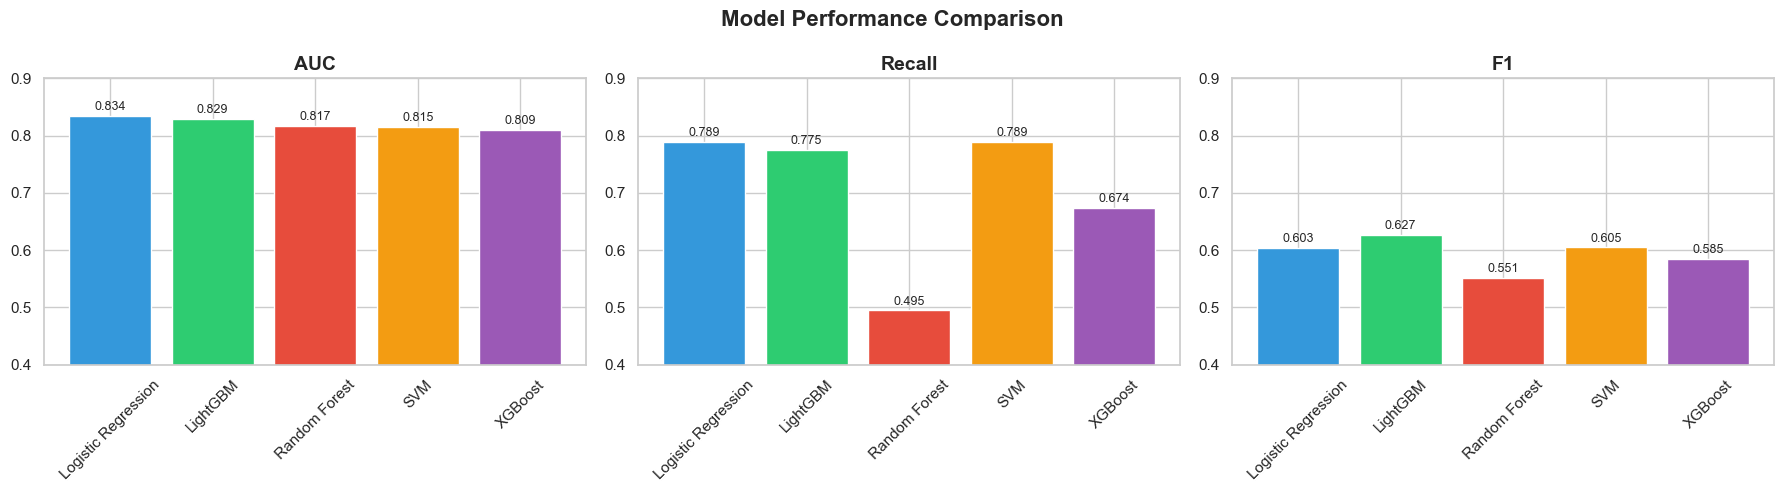

In [4]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['AUC', 'Recall', 'F1']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.4, 0.9)
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


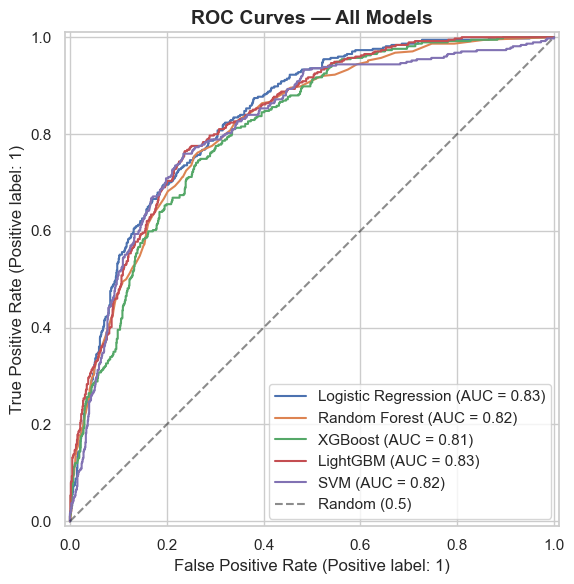

In [5]:
# ROC curves overlay
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_processed, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (0.5)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\nadea\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


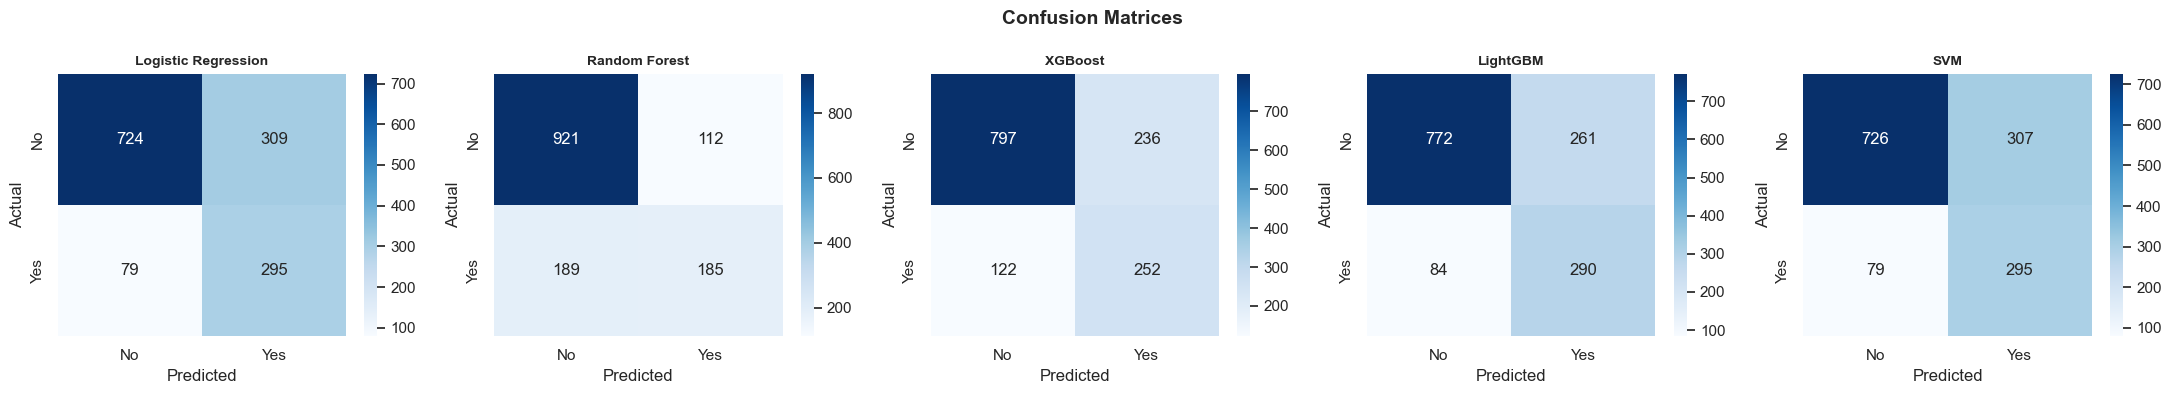

In [6]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Select best model based on AUC (our primary metric)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"  AUC:    {results_df.iloc[0]['AUC']:.4f}")
print(f"  Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"  F1:     {results_df.iloc[0]['F1']:.4f}")

# Save the best model
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(models, '../models/all_models.pkl')

print(f"\nSaved best model ({best_model_name}) to models/best_model.pkl")
print("Saved all models to models/all_models.pkl")

Best model: Logistic Regression
  AUC:    0.8344
  Recall: 0.7888
  F1:     0.6033

Saved best model (Logistic Regression) to models/best_model.pkl
Saved all models to models/all_models.pkl


## Phase 4 Summary

**5 models trained and compared:**

| Model | AUC | Recall | F1 |
|-------|-----|--------|----|
| Logistic Regression | 0.8344 | 0.7888 | 0.6033 |
| LightGBM | 0.8292 | 0.7754 | 0.6270 |
| Random Forest | 0.8170 | 0.4947 | 0.5514 |
| SVM | 0.8151 | 0.7888 | 0.6045 |
| XGBoost | 0.8095 | 0.6738 | 0.5847 |

**Best model: Logistic Regression** — highest AUC and recall (our priority metric for churn). This is a strong interview talking point: the simplest model outperformed the ensemble methods, demonstrating that model complexity doesn't always win.

**Saved:** best_model.pkl, all_models.pkl, model_comparison.csv, all figures